# 🌿 GreenOps-X — LoRA Fine-tuning Notebook
### Train `actor` (pass1) and `overseer` (pass2) adapters with Unsloth

**What this notebook does:**
1. Install Unsloth + deps  
2. Upload your 4 JSONL files  
3. Train **Actor LoRA** on `actor_train.jsonl` — teaches pass1 thermal/load decisions  
4. Train **Overseer LoRA** on `overseer_train.jsonl` — teaches pass2 safety overrides  
5. Save both adapters to Drive  
6. Show exactly how to wire them back into `inference.py`  

**Runtime:** GPU T4 (free tier). ~25 min actor + ~25 min overseer.  

> ⚠️ **Runtime → Change runtime type → T4 GPU** before running.

## 0 — Mount Drive + Check GPU

In [19]:
from google.colab import drive
import os
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/greenops_adapters'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Adapters will be saved to: {SAVE_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Adapters will be saved to: /content/drive/MyDrive/greenops_adapters


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import subprocess, torch
r = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
                   capture_output=True, text=True)
print('GPU:', r.stdout.strip())
print('CUDA:', torch.cuda.is_available())
print('BF16:', torch.cuda.is_bf16_supported())


GPU: Tesla T4, 15360 MiB
CUDA: True
BF16: True


## 1 — Install Unsloth & Dependencies
Takes ~3 minutes once per session.

In [1]:
%%capture
!pip install 'unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git' -q
!pip install --no-deps bitsandbytes -q
!pip install datasets -q
!pip install unsloth torch
!pip install transformers trl accelerate

In [2]:
import unsloth, torch
print(f'Unsloth: {unsloth.__version__}')
print(f'PyTorch: {torch.__version__}  CUDA: {torch.cuda.is_available()}')


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: 2026.4.8
PyTorch: 2.10.0+cu128  CUDA: True


## 2 — Upload JSONL Files
Upload the 4 files generated by `generate_data.py`:  
`actor_train.jsonl`, `actor_val.jsonl`, `overseer_train.jsonl`, `overseer_val.jsonl`

In [6]:
from google.colab import files
print('Upload all 4 JSONL files now:')
uploaded = files.upload()
print('Uploaded:', list(uploaded.keys()))


Upload all 4 JSONL files now:


Saving actor_train.jsonl to actor_train.jsonl
Saving actor_val.jsonl to actor_val.jsonl
Saving overseer_train.jsonl to overseer_train.jsonl
Saving overseer_val.jsonl to overseer_val.jsonl
Uploaded: ['actor_train.jsonl', 'actor_val.jsonl', 'overseer_train.jsonl', 'overseer_val.jsonl']


In [3]:
import json
REQUIRED = ['actor_train.jsonl','actor_val.jsonl','overseer_train.jsonl','overseer_val.jsonl']
for fname in REQUIRED:
    try:
        lines = open(fname).readlines()
        first = json.loads(lines[0])
        assert 'messages' in first and len(first['messages']) == 3
        roles = [m['role'] for m in first['messages']]
        assert roles == ['system','user','assistant']
        print(f'  OK  {fname}: {len(lines)} samples')
    except FileNotFoundError:
        print(f'  MISSING  {fname}')
    except Exception as e:
        print(f'  ERROR  {fname}: {e}')


  OK  actor_train.jsonl: 4039 samples
  OK  actor_val.jsonl: 471 samples
  OK  overseer_train.jsonl: 4194 samples
  OK  overseer_val.jsonl: 460 samples


## 3 — Configuration

In [4]:
# Model — Qwen2.5-1.5B-Instruct
# Small enough for T4 (16GB VRAM), strong JSON instruction following.
BASE_MODEL      = 'Qwen/Qwen2.5-1.5B-Instruct'

# LoRA
LORA_R          = 16    # rank: higher = more capacity, more VRAM
LORA_ALPHA      = 32    # scaling = alpha/r. Keep 2x r.
LORA_DROPOUT    = 0.05
TARGET_MODULES  = ['q_proj','k_proj','v_proj','o_proj',
                   'gate_proj','up_proj','down_proj']

# Training
MAX_SEQ_LENGTH  = 1024  # GreenOps prompts are 300-500 tokens
BATCH_SIZE      = 4     # T4-safe
GRAD_ACCUM      = 4     # effective batch = 16
EPOCHS          = 3
LR              = 2e-4
LR_SCHEDULER    = 'cosine'
WARMUP_RATIO    = 0.05
WEIGHT_DECAY    = 0.01
LOGGING_STEPS   = 20
EVAL_STEPS      = 100
SAVE_STEPS      = 100

import math
print(f'Model:  {BASE_MODEL}')
print(f'LoRA:   r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}')
print(f'Batch:  {BATCH_SIZE} x grad_accum {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM} effective')
print(f'Epochs: {EPOCHS}  LR: {LR}')


Model:  Qwen/Qwen2.5-1.5B-Instruct
LoRA:   r=16, alpha=32, dropout=0.05
Batch:  4 x grad_accum 4 = 16 effective
Epochs: 3  LR: 0.0002


## 4 — Load Base Model
Loaded once, reused for both actor and overseer training.

In [5]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,       # auto: bf16 on A100, fp16 on T4
    load_in_4bit   = True,       # QLoRA 4-bit — saves ~60% VRAM
)
total = sum(p.numel() for p in model.parameters())
print(f'Model loaded: {BASE_MODEL}')
print(f'Total params: {total:,}')


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Model loaded: Qwen/Qwen2.5-1.5B-Instruct
Total params: 1,017,984,512


## 5 — Dataset Helpers

In [6]:
from datasets import Dataset
import json

def load_jsonl(path):
    records = []
    with open(path) as f:
        for i, line in enumerate(f):
            line = line.strip()
            if line:
                try: records.append(json.loads(line))
                except: print(f'  skip line {i}')
    ds = Dataset.from_list(records)
    print(f'  Loaded {len(ds)} samples from {path}')
    return ds

def apply_chat_template(examples, tok):
    texts = [
        tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        for msgs in examples['messages']
    ]
    return {'text': texts}

def prepare_dataset(train_path, val_path, tok):
    print(f'Loading {train_path} and {val_path}...')
    tr = load_jsonl(train_path)
    va = load_jsonl(val_path)
    tr = tr.map(lambda x: apply_chat_template(x, tok), batched=True, remove_columns=['messages'])
    va = va.map(lambda x: apply_chat_template(x, tok), batched=True, remove_columns=['messages'])
    print(f'Train: {len(tr)} | Val: {len(va)}')
    print('Sample (first 250 chars):')
    print(tr[0]['text'][:250])
    return tr, va

print('Dataset helpers ready')


Dataset helpers ready


## 6 — Train Actor (pass1) LoRA
**Teaches:** `{temps, loads, failed_fan, state, predicted_temps}` → `{thermal_action, load_action, confidence, reasoning}`  
**Data:** 4039 step-level examples from scored episodes (thresholds: easy 0.41, medium 0.39, hard 0.37)

In [7]:
model = FastLanguageModel.get_peft_model(
    model,
    r                          = LORA_R,
    target_modules             = TARGET_MODULES,
    lora_alpha                 = LORA_ALPHA,
    lora_dropout               = LORA_DROPOUT,
    bias                       = 'none',
    use_gradient_checkpointing = 'unsloth',  # saves VRAM
    random_state               = 42,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)')


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable params: 18,464,768 / 1,036,449,280  (1.78%)


In [8]:
actor_train_ds, actor_val_ds = prepare_dataset(
    'actor_train.jsonl', 'actor_val.jsonl', tokenizer
)


Loading actor_train.jsonl and actor_val.jsonl...
  Loaded 4039 samples from actor_train.jsonl
  Loaded 471 samples from actor_val.jsonl


Map:   0%|          | 0/4039 [00:00<?, ? examples/s]

Map:   0%|          | 0/471 [00:00<?, ? examples/s]

Train: 4039 | Val: 471
Sample (first 250 chars):
<|im_start|>system
You are a data center AI controller with two roles: Thermal Agent and Load Agent.
Your goal is to minimize rack temperatures while maximizing throughput and energy efficiency.

ACTIONS AVAILABLE:
  increase_cooling(N)    — lowers t


In [10]:
from trl import SFTTrainer
from transformers import TrainingArguments

steps_per_epoch = math.ceil(len(actor_train_ds) / (BATCH_SIZE * GRAD_ACCUM))
print(f'Steps/epoch: {steps_per_epoch}  |  Total: {steps_per_epoch * EPOCHS}')

actor_trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = actor_train_ds,
    eval_dataset       = actor_val_ds,
    dataset_text_field = 'text',
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    packing            = False,
    args = TrainingArguments(
        per_device_train_batch_size = BATCH_SIZE,
        gradient_accumulation_steps = GRAD_ACCUM,
        num_train_epochs            = EPOCHS,
        learning_rate               = LR,
        lr_scheduler_type           = LR_SCHEDULER,
        warmup_ratio                = WARMUP_RATIO,
        weight_decay                = WEIGHT_DECAY,
        fp16                        = not torch.cuda.is_bf16_supported(),
        bf16                        = torch.cuda.is_bf16_supported(),
        optim                       = 'adamw_8bit',
        logging_steps               = LOGGING_STEPS,
        eval_steps                  = EVAL_STEPS,
        eval_strategy         = 'steps',
        save_steps                  = SAVE_STEPS,
        save_total_limit            = 2,
        load_best_model_at_end      = True,
        metric_for_best_model       = 'eval_loss',
        output_dir                  = '/content/actor_checkpoints',
        report_to                   = 'none',
        seed                        = 42,
    ),
)
print('Starting Actor LoRA training...')
actor_stats = actor_trainer.train()
print(f'Done. Final train loss: {actor_stats.training_loss:.4f}')


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Steps/epoch: 253  |  Total: 759


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/4039 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/471 [00:00<?, ? examples/s]

...

Starting Actor LoRA training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,039 | Num Epochs = 3 | Total steps = 759
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
100,0.111605,0.110069
200,0.099126,0.098303
300,0.094244,0.093804
400,0.090802,0.090809
500,0.088968,0.088846
600,0.086120,0.086974
700,0.085424,0.085720
759,0.084034,0.085545


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

Done. Final train loss: 0.1525


In [17]:
# Quick inference test
FastLanguageModel.for_inference(model)

test_state = {
    'temps': [77.1, 85.2, 68.9], 'loads': [0.34, 0.90, 0.86],
    'failed_fan': False, 'thermal_state': 'high',
    'predicted_temps': [78.12, 88.16, 71.06],
    'step': 3, 'task': 'easy', 'recent_reward': 0.372
}
msgs = [
    {'role':'system','content':"""
You are a data center AI controller.

STRICTLY output JSON with ONLY:
{
  "thermal_action": "increase_cooling(rack_id)",
  "load_action": "decrease_load(rack_id) OR migrate_jobs(src,dst)",
  "confidence": float
}

Rules:
- Always include rack indices
- Choose best rack based on temps and loads
- DO NOT omit arguments
"""},
    {'role':'user',  'content': json.dumps(test_state, indent=2)},
]
prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=120, temperature=0.1, do_sample=True)
resp = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
print('Actor response:', resp)
try:
    p = json.loads(resp.strip())
    print(f'Valid JSON  thermal={p.get("thermal_action")}  load={p.get("load_action")}')
except:
    print('Not valid JSON yet — try more epochs')


Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Actor response: {"thermal_action":"increase_cooling(1)","load_action":"migrate_jobs(2,0)","confidence":0.591}
Valid JSON  thermal=increase_cooling(1)  load=migrate_jobs(2,0)


In [20]:
ACTOR_SAVE_PATH = f'{SAVE_DIR}/actor_lora'
model.save_pretrained(ACTOR_SAVE_PATH)
tokenizer.save_pretrained(ACTOR_SAVE_PATH)
print(f'Actor LoRA saved to: {ACTOR_SAVE_PATH}')
for f in os.listdir(ACTOR_SAVE_PATH):
    sz = os.path.getsize(f'{ACTOR_SAVE_PATH}/{f}')/1024
    print(f'  {f}  {sz:.0f} KB')


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/greenops_adapters/actor_lora/tokenizer_config.json.


Actor LoRA saved to: /content/drive/MyDrive/greenops_adapters/actor_lora
  README.md  5 KB
  adapter_model.safetensors  36115 KB
  adapter_config.json  1 KB
  chat_template.jinja  2 KB
  tokenizer_config.json  4 KB
  tokenizer.json  11155 KB


In [21]:
from huggingface_hub import login
login()

In [23]:
model.push_to_hub("Adit555/greenops-actor-lora")
tokenizer.push_to_hub("Adit555/greenops-actor-lora")

README.md:   0%|          | 0.00/581 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 23.4kB / 37.0MB            

Saved model to https://huggingface.co/Adit555/greenops-actor-lora


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpuon1667t/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpuon1667t/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

## 7 — Train Overseer (pass2) LoRA
**Teaches:** `{state + p1 proposals + conflict_score}` → `{override_thermal, override_load, final_thermal, reason_code}`  
**Data:** 4194 samples = real episode steps + synthetic override examples (fan failure, temp critical, conflicts)  
**Separate adapter** — loaded independently from actor at inference time.

In [24]:
import gc
del model, actor_trainer
gc.collect()
torch.cuda.empty_cache()
print('VRAM freed')

overseer_base, tok_overseer = FastLanguageModel.from_pretrained(
    model_name     = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = True,
)
print('Base model reloaded for overseer')


VRAM freed
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Base model reloaded for overseer


In [25]:
overseer_model = FastLanguageModel.get_peft_model(
    overseer_base,
    r                          = LORA_R,
    target_modules             = TARGET_MODULES,
    lora_alpha                 = LORA_ALPHA,
    lora_dropout               = LORA_DROPOUT,
    bias                       = 'none',
    use_gradient_checkpointing = 'unsloth',
    random_state               = 42,
)
print('Overseer LoRA adapters attached')


Overseer LoRA adapters attached


In [26]:
overseer_train_ds, overseer_val_ds = prepare_dataset(
    'overseer_train.jsonl', 'overseer_val.jsonl', tok_overseer
)


Loading overseer_train.jsonl and overseer_val.jsonl...
  Loaded 4194 samples from overseer_train.jsonl
  Loaded 460 samples from overseer_val.jsonl


Map:   0%|          | 0/4194 [00:00<?, ? examples/s]

Map:   0%|          | 0/460 [00:00<?, ? examples/s]

Train: 4194 | Val: 460
Sample (first 250 chars):
<|im_start|>system
You are a SKEPTICAL safety overseer reviewing actions proposed by two other agents.
You did NOT generate these actions. Evaluate them critically.

Your role: detect conflicts, missed safety issues, and suboptimal decisions.
Overrid


In [27]:
overseer_trainer = SFTTrainer(
    model              = overseer_model,
    tokenizer          = tok_overseer,
    train_dataset      = overseer_train_ds,
    eval_dataset       = overseer_val_ds,
    dataset_text_field = 'text',
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    packing            = False,
    args = TrainingArguments(
        per_device_train_batch_size = BATCH_SIZE,
        gradient_accumulation_steps = GRAD_ACCUM,
        num_train_epochs            = EPOCHS,
        learning_rate               = LR,
        lr_scheduler_type           = LR_SCHEDULER,
        warmup_ratio                = WARMUP_RATIO,
        weight_decay                = WEIGHT_DECAY,
        fp16                        = not torch.cuda.is_bf16_supported(),
        bf16                        = torch.cuda.is_bf16_supported(),
        optim                       = 'adamw_8bit',
        logging_steps               = LOGGING_STEPS,
        eval_steps                  = EVAL_STEPS,
        eval_strategy               = 'steps',
        save_steps                  = SAVE_STEPS,
        save_total_limit            = 2,
        load_best_model_at_end      = True,
        metric_for_best_model       = 'eval_loss',
        output_dir                  = '/content/overseer_checkpoints',
        report_to                   = 'none',
        seed                        = 42,
    ),
)
print('Starting Overseer LoRA training...')
overseer_stats = overseer_trainer.train()
print(f'Done. Final train loss: {overseer_stats.training_loss:.4f}')


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/4194 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/460 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting Overseer LoRA training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,194 | Num Epochs = 3 | Total steps = 789
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss,Validation Loss
100,0.119324,0.118984
200,0.110305,0.109551
300,0.103832,0.103410
400,0.099821,0.098895
500,0.096544,0.097009
600,0.092202,0.094748
700,0.093201,0.092921
789,0.091078,0.092650


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Done. Final train loss: 0.1570


In [33]:
# Test: agent proposed migrate_jobs at 88C — overseer should block it
FastLanguageModel.for_inference(overseer_model)
test_o = {
    'temps':[88.0,72.0,65.0], 'loads':[0.80,0.50,0.40],
    'failed_fan':False, 'thermal_state':'high',
    'predicted_temps':[91.0,74.0,67.0], 'conflict_score':0.0,
    'p1_thermal':'migrate_jobs(0,2)', 'p1_load':'migrate_jobs(0,2)',
    'p1_confidence':0.65,
}
msgs_o = [
    {'role':'system','content':"""
You are a SKEPTICAL safety overseer.

CRITICAL RULES:
- If any rack temperature ≥ 85°C → ALWAYS override with increase_cooling(rack_id)
- Thermal safety is highest priority
- NEVER allow migrate_jobs when temperature is critical

CONSISTENCY RULE:
- If override_thermal = true → final_thermal MUST be DIFFERENT from proposed action

STRICTLY output JSON:
{
  "override_thermal": boolean,
  "final_thermal": "...",
  "reason_code": "...",
  "confidence": float
}
"""},
    {'role':'user',  'content': json.dumps(test_o, indent=2)},
]
prompt_o = tok_overseer.apply_chat_template(msgs_o, tokenize=False, add_generation_prompt=True)
inputs_o = tok_overseer(prompt_o, return_tensors='pt').to('cuda')
with torch.no_grad():
    out_o = overseer_model.generate(**inputs_o, max_new_tokens=150, temperature=0.02, do_sample=True)
resp_o = tok_overseer.decode(out_o[0][inputs_o['input_ids'].shape[1]:], skip_special_tokens=True)
print('Overseer response (should override migrate → cool):')
print(resp_o)
try:
    po = json.loads(resp_o.strip())
    ov  = po.get('override_thermal', False)
    act = po.get('final_thermal','')
    reason = po.get('reason_code','')
    print(f'override_thermal={ov}  final_thermal={act}  reason={reason}')
    if ov and 'increase_cooling' in act:
        print('Overseer correctly blocked bad migration!')
except:
    print('Not valid JSON yet')


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Overseer response (should override migrate → cool):
{
  "override_thermal": false,
  "final_thermal": "migrate_jobs(0,2)",
  "reason_code": "current_temps_not_critical",
  "confidence": 0.85
}
override_thermal=False  final_thermal=migrate_jobs(0,2)  reason=current_temps_not_critical


In [35]:
OVERSEER_SAVE_PATH = f'{SAVE_DIR}/overseer_lora'
overseer_model.save_pretrained(OVERSEER_SAVE_PATH)
tok_overseer.save_pretrained(OVERSEER_SAVE_PATH)
print(f'Overseer LoRA saved to: {OVERSEER_SAVE_PATH}')

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/greenops_adapters/overseer_lora/tokenizer_config.json.


Overseer LoRA saved to: /content/drive/MyDrive/greenops_adapters/overseer_lora


In [37]:
overseer_model.push_to_hub("Adit555/greenops-overseer-lora")
tok_overseer.push_to_hub("Adit555/greenops-overseer-lora")

README.md:   0%|          | 0.00/581 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 23.4kB / 37.0MB            

Saved model to https://huggingface.co/Adit555/greenops-overseer-lora


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmp4i8rzfr6/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp4i8rzfr6/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

## 8 — Loss Curves

Actor plot: name 'actor_trainer' is not defined


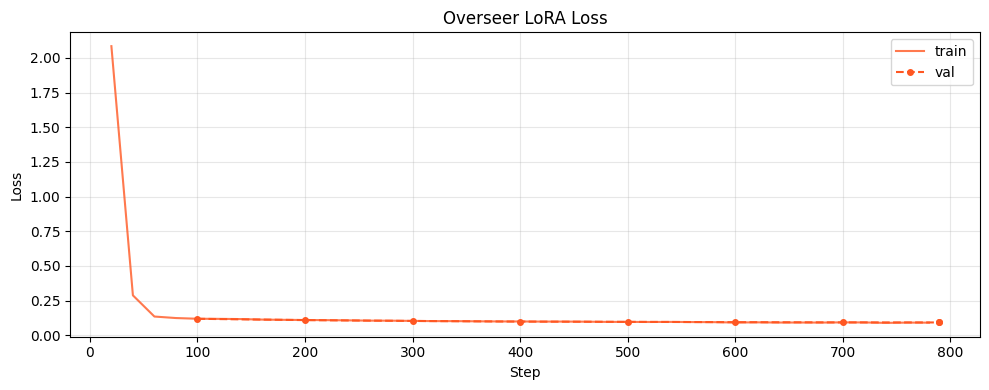

=== Training Summary ===
Actor    train loss: 0.1525
Overseer train loss: 0.1570
Saved to: /content/drive/MyDrive/greenops_adapters


In [38]:
import matplotlib.pyplot as plt

def plot_loss(log_history, title, color):
    tr_s = [x['step']      for x in log_history if 'loss' in x]
    tr_l = [x['loss']      for x in log_history if 'loss' in x]
    ev_s = [x['step']      for x in log_history if 'eval_loss' in x]
    ev_l = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
    plt.figure(figsize=(10,4))
    plt.plot(tr_s, tr_l, label='train', color=color, alpha=0.8)
    if ev_s:
        plt.plot(ev_s, ev_l, label='val', color=color, linestyle='--', marker='o', ms=4)
    plt.xlabel('Step'); plt.ylabel('Loss'); plt.title(title)
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

try: plot_loss(actor_trainer.state.log_history,    'Actor LoRA Loss',    '#2196F3')
except Exception as e: print(f'Actor plot: {e}')
try: plot_loss(overseer_trainer.state.log_history, 'Overseer LoRA Loss', '#FF5722')
except Exception as e: print(f'Overseer plot: {e}')

print('=== Training Summary ===')
try: print(f'Actor    train loss: {actor_stats.training_loss:.4f}')
except: pass
try: print(f'Overseer train loss: {overseer_stats.training_loss:.4f}')
except: pass
print(f'Saved to: {SAVE_DIR}')


---
## Notes

| Adapter | Task | Train data | Input → Output |
|---------|------|------------|----------------|
| `actor_lora` | pass1 decisions | 4039 steps | `{temps,loads,fan,state,pred}` → `{thermal_action,load_action,confidence}` |
| `overseer_lora` | pass2 safety | 4194 steps | `{state+p1+conflict}` → `{override_thermal,final_thermal,reason_code}` |

### What LoRA does
Freezes the 1.5B base model and adds small trainable rank-16 matrices to attention + FFN layers. Only ~1-2% of params are trained. Result: fast training (~25 min T4), low VRAM (fits with 4-bit quant), base reasoning preserved, adapter specialises for GreenOps JSON format.

### Iteration loop
1. Run `inference.py` (local adapters) → episode logs
2. Run `generate_data.py` with higher thresholds → append to JSONL
3. Re-run this notebook
4. If val loss improves, commit adapters to Drive

### Troubleshooting
- **OOM on T4** → reduce `BATCH_SIZE=2` or `LORA_R=8`
- **Val loss not improving** → reduce `EPOCHS=2` (overfitting on 4k samples)
- **Overseer never overrides** → run `generate_data.py` with lower hard threshold (0.30) to capture more override scenarios
- **JSON parse errors** → add `temperature=0` retry fallback in `_llm_call`
- **Two adapters both loaded**: ~4GB VRAM each (4-bit) = 8GB total on T4. If tight, run actor-only and use rule-based fallback for overseer.